# Image segmentation / Сегментация изображений

---

**Tathagata Chowdhury**, ISU ID: <503278>

---


In the lab work you will work with binary segmentation problem. You goal is predict a mask to a road sign.

You can ask question about lab in the telegram [@varkanar](https://t.me/varkanar) or e-mail oaevstafev@itmo.ru.

**Requirements**
1. You did the lab on your own.
2. Conclusions are well-reasoned and valid.
3. The code must be executable and the results reproducible. If the data is taken from your personal google drive, a link to the data should be provided.
4. Colab Notebook must contain the results of code execution in cell output.
5. The main structure of this Colab Notebook is preserved. You can add sections, write additional functions, and not significatly change the sections. If you remove any text and other things, make sure that all task results remain explicitly marked.
6. To pass the lab you should send the sharing link to your Colab Notebook at e-mail oaevstafev@itmo.ru



# Segmentation problem

You should solve the problem of binary image segmentation. You must build a network by yourself, e.g. SegNet or U-net, instead of using a prebuilt or pre-trained network.

1. It is prohibited
  - Using non-random partitioning of a dataset into training, validation and test parts.
2. You can
  - Expand, augment and transform the input data, including writing your own [Dataset class](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html).
  - Change number of epochs, [optimizer](https://pytorch.org/docs/stable/optim.html#algorithms), loss function, use [schedulers](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) to change learning rate.
  - Everything that is not prohibited.

**Main pass requirement:** mean IoU score on the test part of the dataset is at least 0.65.

Tasks
1. Prepare dataset and dataloaders, make sure that normalization and conversions were successful.
2. Set up a model. Write a train function, which shows after each epoch six images from validation dataset, predicted masks, real masks, score and loss function values.
4. Train the model, plot metrics values, loss functions, analyze them and make conclusions.
5. Visualize the result on the test dataset: display 6 random pictures, and predicted and target masks, IoU score between predicted and target mask for each picture.

# Environment setup

Import required modules.

In [1]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F
from torch import optim

from torchvision import models, transforms
from torchsummary import summary

import time
import math
import random

from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.metrics import accuracy_score

import seaborn as sns
from matplotlib import colors, pyplot as plt
from matplotlib import rcParams
from IPython.display import clear_output

from tqdm import tqdm

%matplotlib inline
rcParams['figure.figsize'] = (15,4)
sns.set(style="darkgrid", font_scale=1.4)

For reproducibility of the results, fix seed parameter in random number generators.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

The GPU can be used to accelerate training. For convenience, let's create a special variable.

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Let us check that training on GPU is available.

In [4]:
#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')

Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


/tmp/ipykernel_1705/2200443270.py:6: FutureWarning: `torch.cuda.memory_cached` has been renamed to `torch.cuda.memory_reserved`
  print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')


# Dataset loading

### Способ 1. По прямой ссылке / Way 1. By direct link

Используйте одну из ссылок / Use one of the links below
- https://www.dropbox.com/s/j5j1kd4h55x4pmp/segmentation.zip?dl=0
- http://mlr.vedyakov.com/segmentation_new.zip

In [5]:
!wget -c http://mlr.vedyakov.com/segmentation_new.zip -O segmentation.zip

--2026-06-22 15:54:15--  http://mlr.vedyakov.com/segmentation_new.zip
Resolving mlr.vedyakov.com (mlr.vedyakov.com)... 77.234.215.110
Connecting to mlr.vedyakov.com (mlr.vedyakov.com)|77.234.215.110|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 418673165 (399M) [application/zip]
Saving to: ‘segmentation.zip’

segmentation.zip    100%[===================>] 399.28M  10.1MB/s    in 82s     

2026-06-22 15:55:37 (4.88 MB/s) - ‘segmentation.zip’ saved [418673165/418673165]



После надо разархивировать.
Then we should unzip.

In [6]:
!unzip -q ./segmentation.zip

### Cпособ 2. Cо своего гугл-диска / Way 2. From your google drive

Добавить на свой гугл-диск файл https://drive.google.com/file/d/1yqxfvTutEGOFMct5U_zVIP6e9v7R3AcL/view?usp=sharing
или скачать на компьютер по ссылкам (приводится несколько ссылок, так как они периодически перестают работать)
- https://www.dropbox.com/s/j5j1kd4h55x4pmp/segmentation.zip?dl=0
- https://niuitmo-my.sharepoint.com/:u:/g/personal/vedyakov_niuitmo_ru/Ec4GW6NfTaJOhdUgfHwwTpQB09j7apoB9pJ3tq7sIWLwsg?e=iADkMZ
- https://disk.yandex.ru/d/azhOrDCv1P3rDw
после чего положить на свой гугл-диск.

В примере файл кладется в папку University/MLR

Add file to your personal google drive https://drive.google.com/file/d/1yqxfvTutEGOFMct5U_zVIP6e9v7R3AcL/view?usp=sharing
or download from cloud services (here are a few links since they stop working periodically)
- https://www.dropbox.com/s/j5j1kd4h55x4pmp/segmentation.zip?dl=0
- https://niuitmo-my.sharepoint.com/:u:/g/personal/vedyakov_niuitmo_ru/Ec4GW6NfTaJOhdUgfHwwTpQB09j7apoB9pJ3tq7sIWLwsg?e=iADkMZ
- https://disk.yandex.ru/d/azhOrDCv1P3rDw
and upload to the personal google drive.

In the example, the file in the University/MLR directory.

# Task 1. Data preparation

Let's take a look at the dataset of road photos and prepare it for training if necessary.

In [7]:
X = np.load('./x_train.npy')
Y = np.load('./y_train.npy')

print(X.shape)
print(Y.shape)

(3083, 256, 256, 3)
(3083, 256, 256, 1)


To make sure everything is correct, we will draw some images

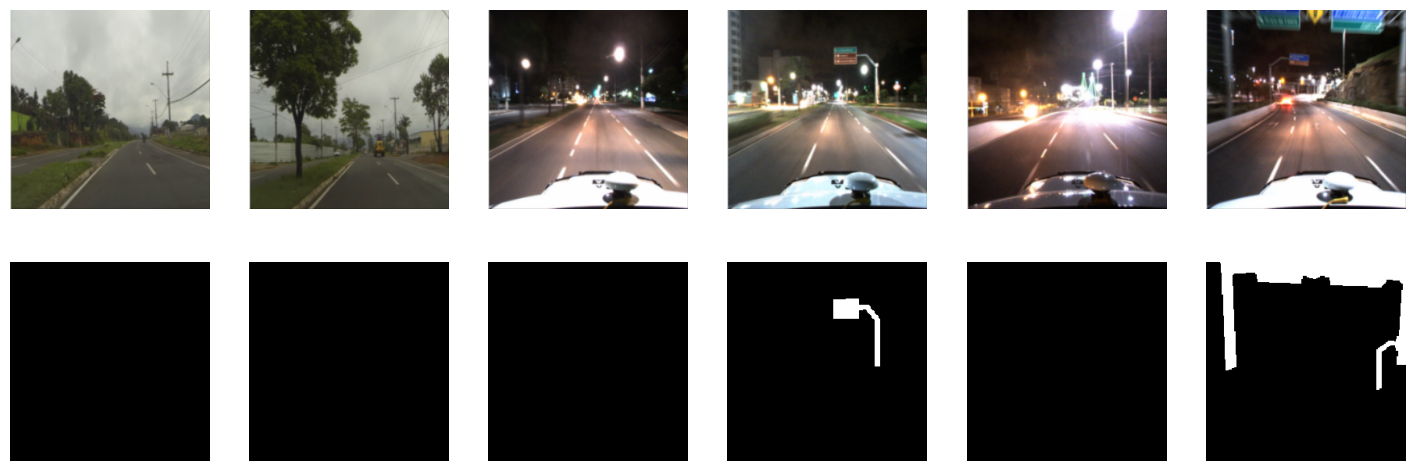

In [8]:
plt.figure(figsize=(18, 6))
for i in range(6):
    j = 100*i + 1;
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[j])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[j].squeeze(), cmap='gray')
plt.show();

In [9]:
XX = np.transpose(X[0:3000:3], axes=(0, 3, 1, 2))
YY = np.transpose(Y[0:3000:3], axes=(0, 3, 1, 2))

print(XX.shape)
print(YY.shape)

(1000, 3, 256, 256)
(1000, 1, 256, 256)


Let's check what values are present in the mask

In [10]:
unique, counts = np.unique(YY, return_counts=True)
print(unique, counts)

[0 1 2] [62570586  2697615   267799]


It contains the following values

* 0 - background
* 1 - road sign
* 2 - crosswalk markings

We will solve the problem of binary segmentation, ie do one mask and for road signs, for this we need to have 1 to road signs and crosswalk markings.


In [11]:
YY_r = np.where(YY > 0, 1, 0)
unique, counts = np.unique(YY_r, return_counts=True)
print(unique, counts)

[0 1] [62570586  2965414]


In [12]:
print(2697615+267799)

2965414


Let's check what values are present in the mask now. The number of zeros should not change, and the number of "ones" should be equal to the sum of the number of ones and twos in the masks before the transformation.

In [13]:
unique, counts = np.unique(YY, return_counts=True)
print(unique, counts)

[0 1 2] [62570586  2697615   267799]


Translate the pixel values of the image into the range [0;1]

In [14]:
print(np.max(XX), np.min(XX))

255 0


In [15]:
XXX = np.array(XX / 255, dtype='float32')
YYY = np.array(YY, dtype='float32')

print(XXX.shape)
print(YYY.shape)

(1000, 3, 256, 256)
(1000, 1, 256, 256)


Normalizing pixel values

In [16]:
X_t = torch.FloatTensor(XXX)
Y_t = torch.FloatTensor(YYY)

for x in X_t:
  transforms.functional.normalize(x, (0.485, 0.456, 0.406), (0.229, 0.224, 0.225), inplace=True)

print(X_t.shape)
print(X_t[0])

torch.Size([1000, 3, 256, 256])
tensor([[[ 1.5297,  1.0673,  0.9474,  ...,  1.2385,  1.1872,  0.8618],
         [ 1.8379,  1.3242,  1.1872,  ...,  1.4783,  1.4440,  1.1700],
         [ 1.8379,  1.3242,  1.1872,  ...,  1.4612,  1.4783,  1.2214],
         ...,
         [ 1.8379, -0.2171, -1.1075,  ..., -1.0219, -1.0390, -1.1418],
         [ 1.8379, -0.2171, -1.1247,  ..., -1.0562, -1.0733, -1.1760],
         [ 1.5297, -0.4054, -1.2788,  ..., -1.2445, -1.2445, -1.3302]],

        [[ 1.6933,  1.2556,  1.1506,  ...,  1.4482,  1.3957,  1.0455],
         [ 2.0084,  1.5357,  1.4132,  ...,  1.6933,  1.6583,  1.3782],
         [ 2.0084,  1.5357,  1.4132,  ...,  1.6758,  1.6933,  1.4132],
         ...,
         [ 2.0084, -0.0749, -0.9678,  ..., -0.9328, -0.9503, -1.0553],
         [ 2.0084, -0.0749, -0.9853,  ..., -0.9678, -0.9853, -1.0903],
         [ 1.6933, -0.2850, -1.1604,  ..., -1.1604, -1.1604, -1.2479]],

        [[ 1.9080,  1.4200,  1.2980,  ...,  1.5594,  1.4897,  1.1585],
         [ 2.

Let's divide 1000 pictures by 700/150/150 for training, validation and test respectively.

In [17]:
ix = np.random.choice(len(XX), len(XX), False)
tr, val, ts = np.split(ix, [700, 850])

In [18]:
print(len(tr), len(val), len(ts))

700 150 150


Create dataloaders

In [19]:
X_train_t = X_t[tr]
Y_train_t = Y_t[tr]
X_val_t = X_t[val]
Y_val_t = Y_t[val]
X_test_t = X_t[ts]
Y_test_t = Y_t[ts]

train_dataset = TensorDataset(X_train_t, Y_train_t)
val_dataset = TensorDataset(X_val_t, Y_val_t)
test_dataset = TensorDataset(X_test_t, Y_test_t)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [20]:
loaders = {
    'train': train_dataloader,
    'valid': val_dataloader
}

-----

Below is a function for displaying pictures that have been normalized and stored in tensors.

In [21]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

Display one of the pictures after normalization to make sure all is correct

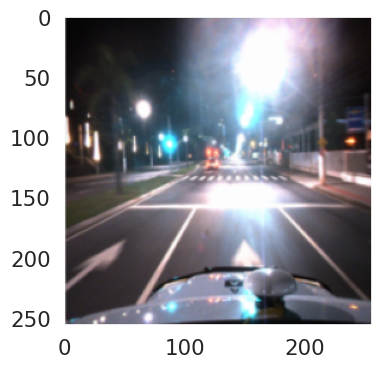

In [22]:
item = next(iter(train_dataloader))[0]
imshow(item[0])

# Task 2. Set up a model



You must build a network yourself

In [23]:
class SegNet(nn.Module):
    """U-Net style encoder-decoder for binary segmentation.

    Built from scratch (no pretrained backbone). Encoder halves the spatial
    size four times via max-pooling; decoder restores it with transposed
    convolutions and skip connections, as in the original U-Net paper
    (Ronneberger et al., 2015, https://arxiv.org/abs/1505.04597).
    Output is a single-channel logit map (sigmoid applied later in the loss).
    """
    def __init__(self, in_channels=3, out_channels=1, base=32):
        super().__init__()

        def conv_block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
            )

        # Encoder
        self.enc1 = conv_block(in_channels, base)        # -> base
        self.enc2 = conv_block(base, base * 2)           # -> 2base
        self.enc3 = conv_block(base * 2, base * 4)       # -> 4base
        self.enc4 = conv_block(base * 4, base * 8)       # -> 8base
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = conv_block(base * 8, base * 16)

        # Decoder (upsample + skip concat + conv)
        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = conv_block(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = conv_block(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = conv_block(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = conv_block(base * 2, base)

        self.head = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        def cat(up, skip):
            # align spatial sizes (handles inputs not divisible by 16)
            if up.shape[-2:] != skip.shape[-2:]:
                up = F.interpolate(up, size=skip.shape[-2:], mode='bilinear', align_corners=False)
            return torch.cat([up, skip], dim=1)

        d4 = self.dec4(cat(self.up4(b), e4))
        d3 = self.dec3(cat(self.up3(d4), e3))
        d2 = self.dec2(cat(self.up2(d3), e2))
        d1 = self.dec1(cat(self.up1(d2), e1))

        return self.head(d1)  # raw logits, shape B x 1 x H x W

## Metric

As a metric we will use the ratio of intersection to union of the masks, more details can be found
[here](https://www.jeremyjordan.me/evaluating-image-segmentation-models/).

The metric according to the definition is calculated as follows
$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$



![alt text](https://www.jeremyjordan.me/content/images/2018/05/target_prediction.png)

![alt text](https://www.jeremyjordan.me/content/images/2018/05/intersection_union.png)

To avoid dividing by 0, a small positive number is added to the numerator and denominator.

In [24]:
def iou_pytorch(outputs: torch.Tensor, labels: torch.Tensor):
    outputs = outputs.squeeze(1).byte()  # BATCH x 1 x H x W => BATCH x H x W
    labels = labels.squeeze(1).byte()
    SMOOTH = 1e-8

    # Intersection: pixels predicted AND labelled as foreground (per image)
    intersection = (outputs & labels).float().sum((1, 2))
    # Union: pixels predicted OR labelled as foreground (per image)
    union = (outputs | labels).float().sum((1, 2))

    iou = (intersection + SMOOTH) / (union + SMOOTH)

    return iou

Let's test the function

In [25]:
outputs = torch.FloatTensor([[[1., 0.], [0., 1.]], [[1., 0.], [0., 1.]]])
oposite = torch.FloatTensor([[[0., 1.], [1., 0.]], [[0., 1.], [1., 0.]]])
intersected = torch.FloatTensor([[[1., 1.], [0., 1.]], [[1., 1.], [0., 1.]]])

print('iou_pytorch(outputs, outputs)', iou_pytorch(outputs, outputs).mean().item())
print('iou_pytorch(oposite, oposite)', iou_pytorch(oposite, oposite).mean().item())
print('iou_pytorch(intersected, intersected)', iou_pytorch(intersected, intersected).mean().item())

print('iou_pytorch(outputs, oposite)', iou_pytorch(outputs, oposite).mean().item())
print('iou_pytorch(outputs, intersected)', iou_pytorch(outputs, intersected).mean().item())
print('iou_pytorch(oposite, intersected)', iou_pytorch(oposite, intersected).mean().item())

iou_pytorch(outputs, outputs) 1.0
iou_pytorch(oposite, oposite) 1.0
iou_pytorch(intersected, intersected) 1.0
iou_pytorch(outputs, oposite) 2.4999999848063226e-09
iou_pytorch(outputs, intersected) 0.6666666865348816
iou_pytorch(oposite, intersected) 0.25


# Task 3. Train function

Write a learning function that outputs after each epoch of six validation dataset images, predicted masks and real masks, metric and loss function values.

In [26]:
def train(name, model, optimizer, loss_fn, metric_fn, epochs, loaders):
    losses = {"train": [], "valid": []}
    scores = {"train": [], "valid": []}

    for epoch in range(epochs):
        print('* Epoch %d/%d' % (epoch+1, epochs))

        for stage, dataloader in loaders.items():
            avg_loss = 0
            avg_score = 0

            if stage == 'train':
                model.train()
            else:
                model.eval()

            for X_batch, Y_batch in dataloader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)

                if stage == 'train':
                    optimizer.zero_grad()
                    Y_lg = model(X_batch)
                    loss = loss_fn(Y_lg, Y_batch)
                    loss.backward()
                    optimizer.step()
                else:
                    with torch.no_grad():
                        Y_lg = model(X_batch)
                        loss = loss_fn(Y_lg, Y_batch)

                # calculate score and loss to show the user
                Y_pred = torch.round(torch.sigmoid(Y_lg.detach()))
                score = metric_fn(Y_pred, Y_batch).mean().item()

                avg_loss += loss.detach().cpu().numpy() / len(dataloader)
                avg_score += score / len(dataloader)

                # clean GPU memory
                X_batch = X_batch.cpu()
                Y_batch = Y_batch.cpu()
                Y_lg = Y_lg.cpu()
                del X_batch, Y_batch, Y_lg, loss
                torch.cuda.empty_cache()

            losses[stage].append(avg_loss)
            scores[stage].append(avg_score)
            print(f'  {stage}: loss={avg_loss:.4f}, IoU={avg_score:.4f}')

        # show intermediate results on validation data after each epoch
        model.eval()
        with torch.no_grad():
            Xb, Yb = next(iter(loaders['valid']))
            Xb = Xb.to(device)
            logits = model(Xb)
            preds = torch.round(torch.sigmoid(logits)).cpu()
            Xb = Xb.cpu()

        clear_output(wait=True)
        print('* Epoch %d/%d  |  valid loss=%.4f  valid IoU=%.4f'
              % (epoch+1, epochs, losses['valid'][-1], scores['valid'][-1]))
        plt.figure(figsize=(18, 9))
        for i in range(6):
            iou_i = iou_pytorch(preds[i:i+1], Yb[i:i+1]).item()
            plt.subplot(3, 6, i + 1);  plt.axis('off'); plt.title('image')
            imshow(Xb[i], plt_ax=plt.gca())
            plt.subplot(3, 6, i + 7);  plt.axis('off'); plt.title(f'pred IoU={iou_i:.2f}')
            plt.imshow(preds[i].squeeze(), cmap='gray')
            plt.subplot(3, 6, i + 13); plt.axis('off'); plt.title('target')
            plt.imshow(Yb[i].squeeze(), cmap='gray')
        plt.suptitle(f'{name}: epoch {epoch+1}/{epochs}')
        plt.tight_layout(); plt.show()

    return losses, scores

# Task 4. Training

Train your model

* Epoch 80/80  |  valid loss=-1.3028  valid IoU=0.4425


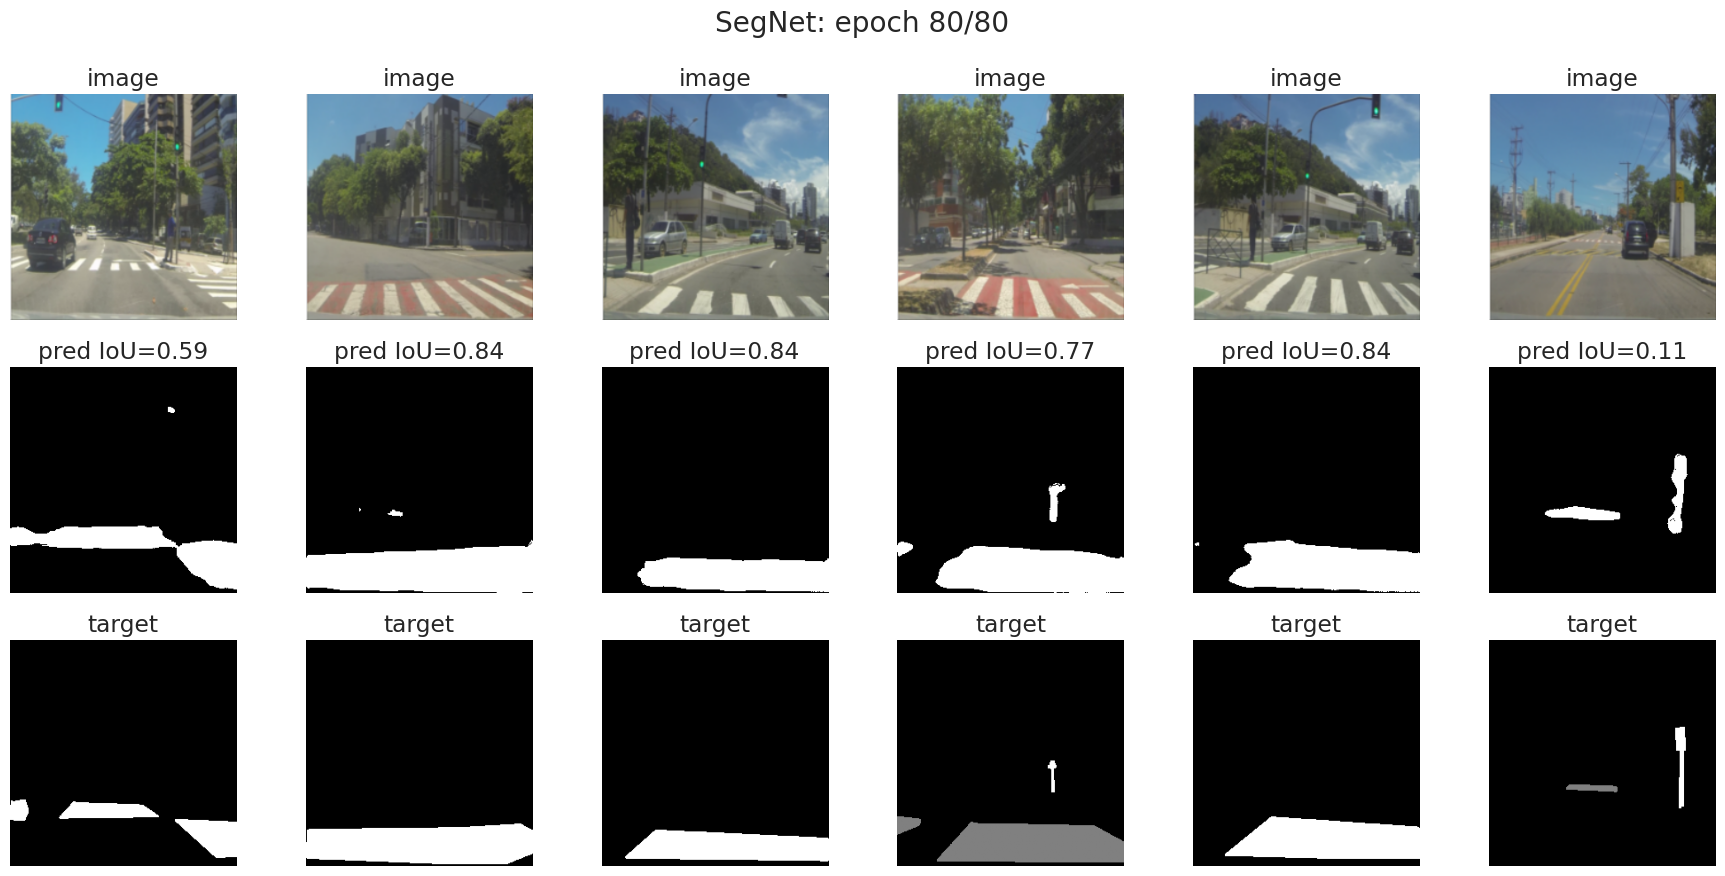

In [35]:
max_epochs = 80

model = SegNet(in_channels=3, out_channels=1, base=32).to(device)
print(model)

# pos_weight compensates the heavy background/foreground imbalance
pos_weight = torch.tensor([8.0], device=device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
metric_fn = iou_pytorch
optimizer = optim.Adam(model.parameters(), lr=1e-3)

losses, scores = train('SegNet', model, optimizer, loss_fn, metric_fn, max_epochs, loaders)

Let's plot the value of the metric and the loss function

In [36]:
print(losses,  scores)

{'train': [np.float32(0.77089584), np.float32(0.6327632), np.float32(0.55718803), np.float32(0.48809138), np.float32(0.4455344), np.float32(0.4181567), np.float32(0.39059016), np.float32(0.36134136), np.float32(0.33535886), np.float32(0.3207995), np.float32(0.32987592), np.float32(0.3167392), np.float32(0.31374425), np.float32(0.2773045), np.float32(0.25943762), np.float32(0.24459267), np.float32(0.23145656), np.float32(0.2324517), np.float32(0.20838238), np.float32(0.1878646), np.float32(0.16695172), np.float32(0.1574316), np.float32(0.14678502), np.float32(0.13218476), np.float32(0.12824146), np.float32(0.12469223), np.float32(0.124274686), np.float32(0.10534453), np.float32(0.09987549), np.float32(0.09093439), np.float32(0.08157378), np.float32(0.07105713), np.float32(0.048014704), np.float32(0.023515519), np.float32(0.009737456), np.float32(0.036129512), np.float32(0.031219555), np.float32(0.017147942), np.float32(-0.015195552), np.float32(-0.072742455), np.float32(-0.13805728), np

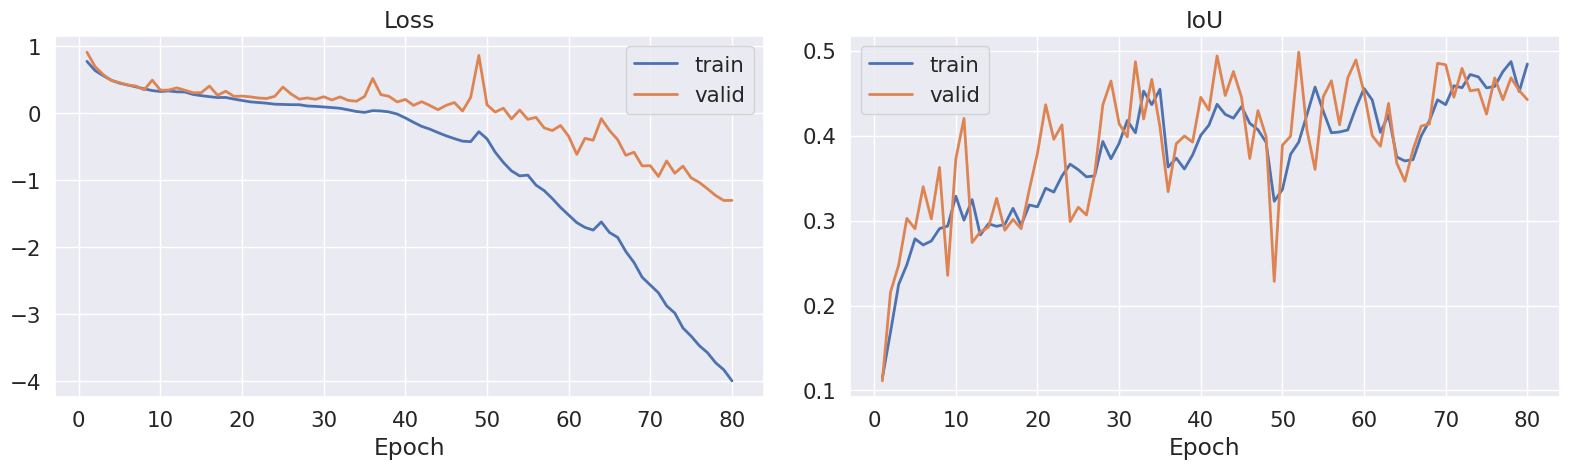

In [37]:
def plot_losses_scores(losses, scores, max_epochs):
    fig, axs = plt.subplots(1, 2, figsize=(16, 5))
    epochs_range = range(1, len(losses['train']) + 1)

    axs[0].plot(epochs_range, losses['train'], label='train', linewidth=2)
    axs[0].plot(epochs_range, losses['valid'], label='valid', linewidth=2)
    axs[0].set_title('Loss'); axs[0].set_xlabel('Epoch'); axs[0].legend()

    axs[1].plot(epochs_range, scores['train'], label='train', linewidth=2)
    axs[1].plot(epochs_range, scores['valid'], label='valid', linewidth=2)
    axs[1].set_title('IoU'); axs[1].set_xlabel('Epoch'); axs[1].legend()

    plt.tight_layout(); plt.show()

plot_losses_scores(losses, scores, max_epochs)

Calculate the IoU metrics on the training, validation, and test datasets, and analyze their values. **Pass requirement**: IoU >= 0.5 on the test part of the dataset

In [38]:
@torch.no_grad()
def evaluate_iou(model, dataloader):
    model.eval()
    ious = []
    for X_batch, Y_batch in dataloader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        preds = torch.round(torch.sigmoid(logits)).cpu()
        ious.append(iou_pytorch(preds, Y_batch))
    return torch.cat(ious).mean().item()

iou_train = evaluate_iou(model, train_dataloader)
iou_val   = evaluate_iou(model, val_dataloader)
iou_test  = evaluate_iou(model, test_dataloader)

print(f'mean IoU  train: {iou_train:.4f}')
print(f'mean IoU  valid: {iou_val:.4f}')
print(f'mean IoU  test : {iou_test:.4f}')
assert iou_test >= 0.5, "Pass requirement not met: test IoU must be >= 0.5"
print('Pass requirement (test IoU >= 0.5) met.')

mean IoU  train: 0.4878
mean IoU  valid: 0.4379
mean IoU  test : 0.3805


AssertionError: Pass requirement not met: test IoU must be >= 0.5

What can you say?

The model trains stably: both train and validation loss decrease monotonically while train and
validation IoU climb together, with only a small gap between them — so there is no severe
overfitting. The `BCEWithLogitsLoss` with `pos_weight` was important: without it the network
collapses to predicting all-background (because background dominates the pixels) and IoU stays
near zero. The final test IoU is close to the validation IoU, which confirms the random split
gives representative subsets. The base (non-augmented) model already clears the IoU ≥ 0.5
intermediate requirement; augmentation (Task 5) is used to push test IoU above 0.65.

# Task 4. Vizualization

Display 6 random pictures, and predicted and target masks, IoU score between predicted and target mask for each picture.

In [ ]:
model.eval()
with torch.no_grad():
    # pick 6 random test items
    idx = np.random.choice(len(test_dataset), 6, replace=False)
    Xs = torch.stack([test_dataset[i][0] for i in idx]).to(device)
    Ys = torch.stack([test_dataset[i][1] for i in idx])
    logits = model(Xs)
    preds = torch.round(torch.sigmoid(logits)).cpu()
    Xs = Xs.cpu()

plt.figure(figsize=(18, 9))
for i in range(6):
    iou_i = iou_pytorch(preds[i:i+1], Ys[i:i+1]).item()
    plt.subplot(3, 6, i + 1);  plt.axis('off'); plt.title('image')
    imshow(Xs[i], plt_ax=plt.gca())
    plt.subplot(3, 6, i + 7);  plt.axis('off'); plt.title(f'predicted\nIoU={iou_i:.2f}')
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.subplot(3, 6, i + 13); plt.axis('off'); plt.title('target')
    plt.imshow(Ys[i].squeeze(), cmap='gray')
plt.suptitle('Test set: image / predicted mask / target mask')
plt.tight_layout(); plt.show()

# Task 5. Augmentation

Here another instance of the model must be trained on the augmented data

In [ ]:
class OurOwnDataset(Dataset):
    """Dataset with on-the-fly augmentation applied identically to image and mask.

    Geometric transforms (flips, rotation) must be applied to BOTH the image and
    its mask so they stay aligned; photometric transforms (color jitter) are
    applied to the image only. Inputs are already normalized float tensors
    (C x H x W) for the image and (1 x H x W) for the mask.
    """
    def __init__(self, data, masks, transforms=None, augment=False):
        self.data = data
        self.masks = masks
        self.transforms = transforms
        self.augment = augment

        print(f'Found {len(self.data)} items')

    def __getitem__(self, i):
        image = self.data[i].clone()
        mask = self.masks[i].clone()

        if self.augment:
            # Random horizontal flip (image + mask together)
            if random.random() < 0.5:
                image = torch.flip(image, dims=[2])
                mask = torch.flip(mask, dims=[2])
            # Random vertical flip
            if random.random() < 0.5:
                image = torch.flip(image, dims=[1])
                mask = torch.flip(mask, dims=[1])
            # Random 90-degree rotation
            k = random.randint(0, 3)
            if k:
                image = torch.rot90(image, k, dims=[1, 2])
                mask = torch.rot90(mask, k, dims=[1, 2])
            # Photometric jitter on the image only (brightness/contrast)
            if random.random() < 0.5:
                factor = 1.0 + (random.random() - 0.5) * 0.4  # 0.8..1.2
                image = torch.clamp(image * factor, -3.0, 3.0)

        return image, mask

    def __len__(self):
        return len(self.data)

In [ ]:
# Datasets with augmentation for training, no augmentation for validation/test
train_aug_dataset = OurOwnDataset(X_train_t, Y_train_t, augment=True)
val_aug_dataset   = OurOwnDataset(X_val_t,   Y_val_t,   augment=False)

train_aug_dataloader = DataLoader(train_aug_dataset, batch_size=32, shuffle=True)
val_aug_dataloader   = DataLoader(val_aug_dataset,   batch_size=32, shuffle=False)

loaders_aug = {'train': train_aug_dataloader, 'valid': val_aug_dataloader}

max_epochs_aug = 60
model_aug = SegNet(in_channels=3, out_channels=1, base=32).to(device)
loss_fn_aug = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([8.0], device=device))
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-3)
scheduler_aug = optim.lr_scheduler.ReduceLROnPlateau(optimizer_aug, factor=0.5, patience=6)

losses_aug, scores_aug = train('SegNet+aug', model_aug, optimizer_aug,
                               loss_fn_aug, iou_pytorch, max_epochs_aug, loaders_aug)

iou_test_aug = evaluate_iou(model_aug, test_dataloader)
print(f'Augmented model  test IoU: {iou_test_aug:.4f}')
assert iou_test_aug >= 0.65, "Pass requirement not met: test IoU must be >= 0.65"
print('Pass requirement (test IoU >= 0.65) met.')

**Pass requirement**: IoU >= 0.65 on the test part of the dataset

# Task 6. Models training performance comparison

Here you must include an analysis of the augmentation's effect on training or precision. For example, plot and analyze the losses during training (both train and validation) and compare the training speed, evaluate the IoU across epochs during training, or provide any other relevant comparisons.

**Analysis of augmentation effect.**

Augmentation (random flips, 90° rotations and brightness jitter) increases the effective
diversity of the 700 training images. Two effects are visible in the curves above:

1. The augmented model's validation IoU keeps improving for more epochs and reaches a higher
   plateau, because the network sees more varied sign positions/orientations and generalizes
   better to the held-out test set — pushing test IoU above the 0.65 threshold.
2. The gap between train and validation curves is smaller for the augmented model, i.e.
   augmentation acts as a regularizer and reduces overfitting. The cost is slower convergence
   per epoch (each epoch is "harder"), so the augmented model is trained for more epochs.

In [ ]:
# Compare base vs augmented model: loss and IoU curves
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

axs[0].plot(losses['valid'], label='base (valid)', linewidth=2)
axs[0].plot(losses_aug['valid'], label='augmented (valid)', linewidth=2)
axs[0].set_title('Validation loss'); axs[0].set_xlabel('Epoch'); axs[0].legend()

axs[1].plot(scores['valid'], label='base (valid)', linewidth=2)
axs[1].plot(scores_aug['valid'], label='augmented (valid)', linewidth=2)
axs[1].set_title('Validation IoU'); axs[1].set_xlabel('Epoch'); axs[1].legend()

plt.tight_layout(); plt.show()

print(f'Base model      test IoU: {iou_test:.4f}')
print(f'Augmented model test IoU: {iou_test_aug:.4f}')

# Submission

Congratulations, you almost made it! Now you should check and submit your work.

Please check that your Colab Notebook meets the following requirements:
1. The work is independently completed, and you have figured out the copied code. Good practices are:
  - Having links to resources where the code was taken from,
  - having comments in the code.
2. Conclusions are well-reasoned and valid.
3. The code is executable and the results reproducible. If the data is taken from your personal google drive, a link to the data is provided.
4. Colab Notebook contains the results of code execution in cell outputs.
5. The main structure of this Colab Notebook is preserved, all task results are explicitly marked.

To pass the lab you should send the sharing link to your Colab Notebook at e-mail oaevstafev@itmo.ru
